In [ ]:
# Definiciones de herramientas ópticas (reflexión y contraste)
import numpy as np
import matplotlib.pyplot as plt


def reflected_intensity(
    wavelength_nm,
    ambient_index,
    flake_index,
    oxide_index,
    substrate_index,
    flake_thickness_nm,
    oxide_thickness_nm,
):
    """
    Calcula la intensidad reflejada para un sistema:
      aire / flake / SiO2 / Si
    usando las ecuaciones de Fresnel para incidencia normal.
    """

    wavelength_nm = np.asarray(wavelength_nm, dtype=np.complex128)

    r1 = (ambient_index - flake_index) / (ambient_index + flake_index)
    r2 = (flake_index - oxide_index) / (flake_index + oxide_index)
    r3 = (oxide_index - substrate_index) / (oxide_index + substrate_index)

    phi1 = 2 * np.pi * flake_index * flake_thickness_nm / wavelength_nm
    phi2 = 2 * np.pi * oxide_index * oxide_thickness_nm / wavelength_nm

    numerator = (
        r1 * np.exp(1j * (phi1 + phi2))
        + r2 * np.exp(-1j * (phi1 - phi2))
        + r3 * np.exp(-1j * (phi1 + phi2))
        + r1 * r2 * r3 * np.exp(1j * (phi1 - phi2))
    )

    denominator = (
        np.exp(1j * (phi1 + phi2))
        + r1 * r2 * np.exp(-1j * (phi1 - phi2))
        + r1 * r3 * np.exp(-1j * (phi1 + phi2))
        + r2 * r3 * np.exp(1j * (phi1 - phi2))
    )

    I = np.abs(numerator / denominator) ** 2
    return np.real_if_close(I)


def optical_contrast(
    wavelength_nm,
    flake_index,
    oxide_index,
    substrate_index,
    flake_thickness_nm,
    oxide_thickness_nm,
    contrast_in_percent=False,
    clip_contrast=None,
):
    """
    Calcula el contraste óptico: C = (I_sub - I_flake) / I_sub
    """

    I_flake = reflected_intensity(
        wavelength_nm=wavelength_nm,
        ambient_index=1,
        flake_index=flake_index,
        oxide_index=oxide_index,
        substrate_index=substrate_index,
        flake_thickness_nm=flake_thickness_nm,
        oxide_thickness_nm=oxide_thickness_nm,
    )

    I_substrate = reflected_intensity(
        wavelength_nm=wavelength_nm,
        ambient_index=1,
        flake_index=1,
        oxide_index=oxide_index,
        substrate_index=substrate_index,
        flake_thickness_nm=0,
        oxide_thickness_nm=oxide_thickness_nm,
    )

    with np.errstate(divide='ignore', invalid='ignore'):
        C = (I_substrate - I_flake) / I_substrate

    if contrast_in_percent:
        C = np.real_if_close(C) * 100.0
    else:
        C = np.real_if_close(C)

    if clip_contrast is not None:
        C = np.clip(C, clip_contrast[0], clip_contrast[1])

    return C


def contrast_vs_wavelength(
    wavelengths_nm,
    flake_index,
    oxide_index,
    substrate_index,
    flake_thickness_nm,
    oxide_thickness_nm,
    contrast_in_percent=False,
    clip_contrast=None,
    precomputed_C=None,
    return_figure=False,
):
    """
    Grafica el contraste óptico en función de la longitud de onda.

    Si se pasa `precomputed_C`, se usa dicho arreglo para dibujar la curva
    (evita recalcular si ya se ha evaluado). Si `return_figure` es True, devuelve
    la figura en lugar de mostrarla (útil para integrar en la GUI).
    """

    wavelengths_nm = np.asarray(wavelengths_nm)

    if precomputed_C is None:
        C = optical_contrast(
            wavelength_nm=wavelengths_nm,
            flake_index=flake_index,
            oxide_index=oxide_index,
            substrate_index=substrate_index,
            flake_thickness_nm=flake_thickness_nm,
            oxide_thickness_nm=oxide_thickness_nm,
            contrast_in_percent=contrast_in_percent,
            clip_contrast=clip_contrast,
        )
    else:
        C = np.asarray(precomputed_C)

    # Valores máximos
    idx_max = int(np.nanargmax(C))
    C_max = float(C[idx_max])
    wavelength_max = float(wavelengths_nm[idx_max])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(wavelengths_nm, C, label='Contraste')
    ax.plot(wavelength_max, C_max, 'ro', label=fr'$\lambda =$ {wavelength_max:.2f} nm')
    ax.set_xlabel('Longitud de onda (nm)')
    ax.set_ylabel('Contraste óptico')
    ax.set_title('Contraste óptico vs longitud de onda')
    ax.grid(True)
    ax.legend()
    fig.tight_layout()

    if return_figure:
        return fig

    plt.show()
    return C


# **Código para predecir el contraste óptico**

En este Notebook se presentan los códigos que permiten hacer una predicción del contraste óptico que es posible ver para un material dado con un cierto índice de refracción complejo. El código está hecho asumiendo que el material que se analiza tiene un espesor del orden de los nanómetros y está sobre un sustrato de SiO2 / Si, en donde la capa de SiO2 está en el orden de los cientos de nanómetros. Sin embargo, todas estas características son variables que se pueden cambiar dentro del código.

Este Notebook permite calcular los parámetros que maximizan y minimizan el contraste óptico en función de los distintos parámetros (índice de refracción del material, grosor del material, grosor de la capa de SiO2, y longitud de onda utilizada).

# **Teoría**

La intensidad reflejada $I(λ)$ en presencia de una capa (un flake) de algún material con índice de refracción complejo $n_1(λ)$ se calcula mediante la siguiente ecuación:

$$I(λ) = \left|\frac{r_a}{r_b}\right|^2$$

Donde

$$r_a = (r_1 e^{i(\phi_1 + \phi_2} + r_2 e^{-i(\phi_1 - \phi_2)} + r_3e^{-i(\phi_1 + \phi_2)} + r_1r_2r_3e^{i(\phi_1-\phi_2)})$$

$$r_b = (e^{i(\phi_1 + \phi_2} + r_1r_2 e^{-i(\phi_1 - \phi_2)} + r_1r_3e^{-i(\phi_1 + \phi_2)} + r_2r_3e^{i(\phi_1-\phi_2)})$$

Con

$$r_1 = \frac{n_0-n_1}{n_0+n_1}, r_2 = \frac{n_1-n_2}{n_1+n_2}, r_3=\frac{n_2-n_3}{n_2+n_3}$$

Y $\phi_1, \phi_2$, las son las fases ópticas del sistema que están dadas por:

$$\phi_1 = \frac{2 \pi n_1 d_1}{λ}, \phi_2 = \frac{2 \pi n_2 d_2}{λ}$$

Siendo $d_1$ y $d_2$, los grosores del flake y de la capa de SiO2, respectivamente.

El contraste óptico se define como:

$$C(λ) = \frac{I_0(λ) - I(λ)}{I_0(λ)}$$

Donde $I_0(λ)$ es el espectro de reflección del sustrato de SiO2/Si, y $I(λ)$ es el espectro de reflección de la capa del material depositado sobre el sustrato.

## Contraste óptico en función de la longitud de onda dados los grosores fijos

## Contraste óptico en función del número de capas dada una longitud de onda fija

## Contraste óptico en función del número del espesor del SiO2 para distintas longitudes de onda dado un número de capas fijo

## Contraste óptico en función del número del espesor del grafito para distintas longitudes de onda dado un grosor del SiO2 fijo

___
# **Grafeno**

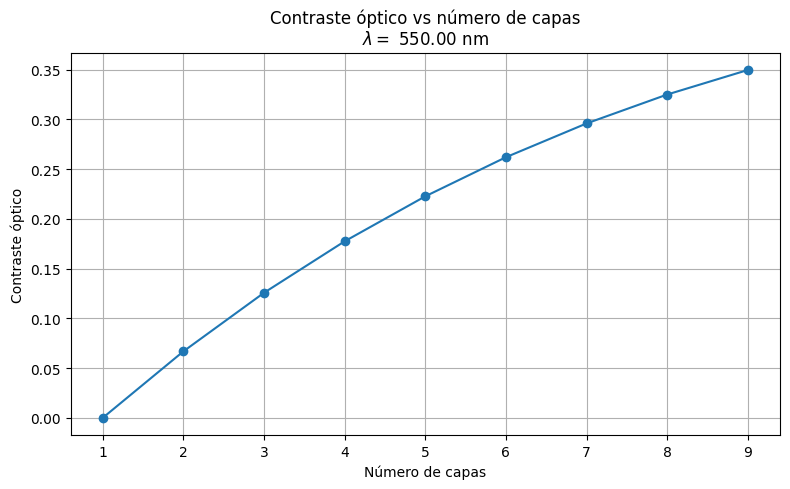

In [92]:
# NÚMERO DE CAPAS
N = 9 #@param

layers = np.arange(0, N)

# LONGITUD DE ONDA FIJA
wavelength_nm = 550  #@param # nm

# ESPESOR MONOCAPA
single_layer_thickness_nm = 0.335  #@param # Grafeno

# ESPESORES TOTALES
flake_thicknesses_nm = layers * single_layer_thickness_nm

contrast_vs_layers(
    wavelength_nm=wavelength_nm,
    flake_index=flake_index,
    oxide_index=oxide_index,
    substrate_index=substrate_index,
    flake_thicknesses_nm=flake_thicknesses_nm,
    oxide_thickness_nm=oxide_thickness_nm
)

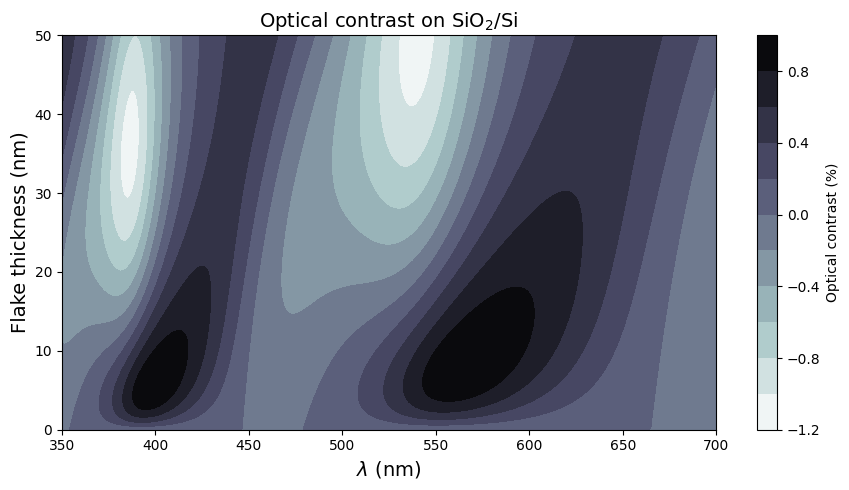

In [94]:
# ESPESOR FIJO DE SiO2
oxide_thickness_nm = 465  #@param # nm

# LONGITUDES DE ONDA
wavelengths_nm = np.linspace(350, 700, 400) #@param

# THICKNESS DEL GRAFITO
flake_thicknesses_nm = np.linspace(0, 50, 300)  #@param # nm

contrast_vs_layers_and_lambda(
    wavelengths_nm=wavelengths_nm,
    flake_index=flake_index,
    oxide_index=oxide_index,
    substrate_index=substrate_index,
    flake_thicknesses_nm=flake_thicknesses_nm,
    oxide_thickness_nm=oxide_thickness_nm
)

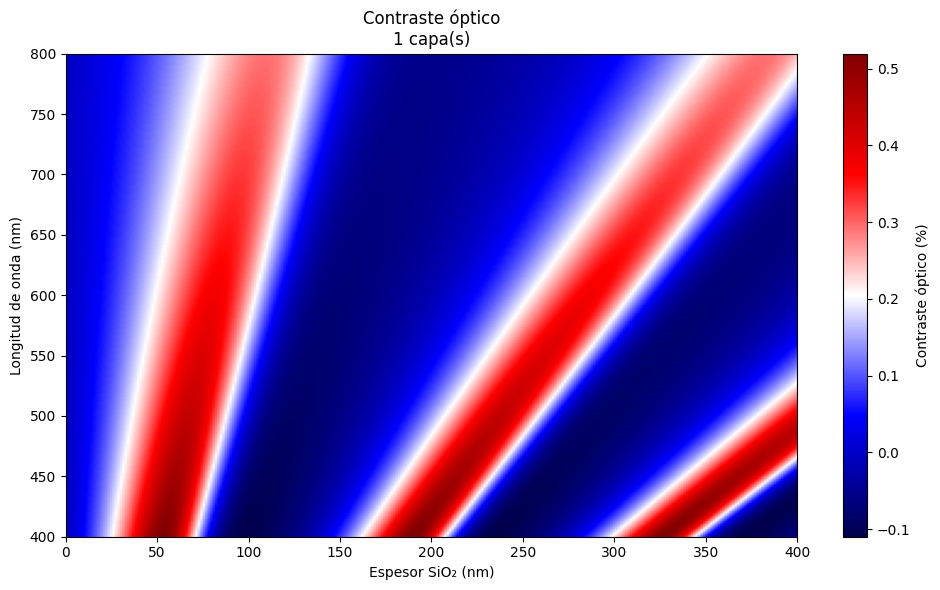

In [95]:
# ÍNDICES DE REFRACCIÓN
flake_index = 5.0 - 1.0j  #@param # MoS2
oxide_index = 1.46        #@param # SiO2
substrate_index = 5.6 - 0.4j  #@param # Si

# NÚMERO DE CAPAS FIJO
layers = 1  #@param

# ESPESOR MONOCAPA
single_layer_thickness_nm = 0.65  #@param # MoS2

# ESPESOR TOTAL DEL FLAKE
flake_thickness_nm = layers * single_layer_thickness_nm

# LONGITUDES DE ONDA
wavelengths_nm = np.linspace(400, 800, 300) #@param

# ESPESORES DE SiO2
oxide_thicknesses_nm = np.linspace(0, 400, 300) #@param

contrast_vs_lambda_and_thickness(
    wavelengths_nm=wavelengths_nm,
    flake_index=flake_index,
    oxide_index=oxide_index,
    substrate_index=substrate_index,
    flake_thickness_nm=flake_thickness_nm,
    oxide_thicknesses_nm=oxide_thicknesses_nm,
    layers=layers
)